# Punch out

Probe the resonator at low amplitude, then high amplitude. See if there's difference.

# General Input

In [1]:
# LabOne Q:
from laboneq.simple import *

# Helpers:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation

import matplotlib.pyplot as plt
import numpy as np
import laboneq
print(laboneq.__version__)
import numpy as np
import matplotlib.pyplot as plt
import time
# Use this if you need to reset
# session.devices[f"SHFQC_{serial_num}"].factory_reset()

2.57.0


# Helper Functions

In [ ]:
def create_readout_pulse(
    qubit, duration = , amplitude=0.9
):
    readout_pulse = pulse_library.const(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
    )
    return readout_pulse

# Descriptor and Basic Setup

In [2]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/0/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)

# Are we emulating? or actually creating pulses? ****
emulate = True
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.19 18:19:21.298] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\24716\Documents\code\python\qubit_design\measurements\basic_characterization\laboneq_output\log
[2025.08.19 18:19:21.301] INFO    VERSION: laboneq 2.57.0
[2025.08.19 18:19:21.304] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.19 18:19:21.307] INFO    Connected to Zurich Instruments LabOne Data Server version 25.07.0.507 at 127.0.0.1:8004
[2025.08.19 18:19:21.312] INFO    Configuring the device setup
[2025.08.19 18:19:21.316] INFO    The device setup is configured


# Experiment Definition

In [3]:
def punch_out(
    exp_id             = "punch_out",
    average_exponent   = 5,
    acq_freq_sweep     = LinearSweepParameter(uid="acquisition_frequency_sweep", start=-600e6, stop=600e6, count=2001),
    integration_length = 2e-6,
):
    # Create Experiment
    exp = Experiment(
        uid = exp_id,
        signals = [
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    readout_pulse = pulse_library.const(uid="readout_pulse", amplitude=0.15)

    with exp.acquire_loop_rt(
        uid="freq_shots", 
        count=pow(2, average_exponent), 
        acquisition_type=AcquisitionType.SPECTROSCOPY,
        ):
        with exp.sweep(uid="acq_freq_sweep", parameter=acq_freq_sweep):
            with exp.section(uid="spectroscopy"):
                exp.play(signal="measure", pulse=readout_pulse),
                exp.acquire(signal="acquire", handle="res_spec"),
    return exp

In [4]:
acq_lo_freq = 7.0e9
acq_res_fre = 7.10e9

acq_fre_swp_st  = (acq_res_fre - 100e6) - 7e9
acq_fre_swp_end = (acq_res_fre + 100e6) - 7e9

acq_fre_swp_cnt = 501


acq_freq_sweep   = LinearSweepParameter(
    uid="acquisition_frequency_sweep", 
    start=acq_fre_swp_st, 
    stop=acq_fre_swp_end, 
    count=acq_fre_swp_cnt)

one_punch_man = punch_out(
    average_exponent = 10,
    acq_freq_sweep = acq_freq_sweep,
    integration_length = 5e-6,
    )
print(acq_freq_sweep)

LinearSweepParameter(
│   uid='acquisition_frequency_sweep',
│   start=0.0,
│   stop=200000000.0,
│   count=501,
│   axis_name=None
)



决定这个实验的名字叫一拳超人，嗯

所以punch out也可以是one_punch_man，opm

In [5]:
map_q0 = {}
map_q0['measure'] = device_setup.logical_signal_groups["q0"].logical_signals["measure_line"]
map_q0['acquire'] = device_setup.logical_signal_groups["q0"].logical_signals["acquire_line"]
one_punch_man.set_signal_map(map_q0)

In [6]:
exp_calibration = Calibration()

exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", 
                            frequency = acq_freq_sweep,
                            modulation_type=ModulationType.HARDWARE),
    local_oscillator = Oscillator(uid="qa_lo", 
                                  frequency = acq_lo_freq),
    range = -30, 
    amplitude= 0.1
)

exp_calibration["acquire"] = SignalCalibration(
    range = -40, 
    amplitude= 1.0
)

one_punch_man.set_calibration(exp_calibration)

In [7]:
compiled_opm = session.compile(one_punch_man)

RuntimeError: Either 'kernel' or 'length' must be provided for the acquire operation with handle 'res_spec'.

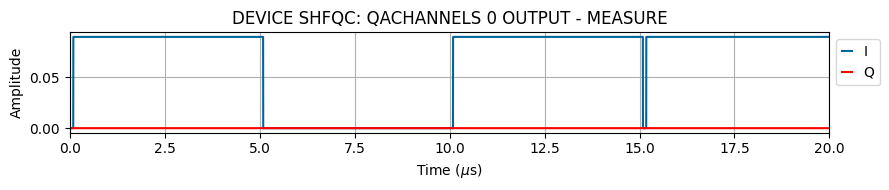

In [ ]:
plot_simulation(compiled_opm, 0, 20e-6)

In [ ]:
run_opm = session.run(compiled_opm)

[2025.08.19 15:35:56.092] WARNING SHFQC/QA:dev12296: Output channel 0 range -40.0 is not on the list of allowed ranges: [-30. -25. -20. -15. -10.  -5.   0.   5.  10.]. Nearest allowed range will be used.
[2025.08.19 15:35:56.094] INFO    Starting near-time execution...
[2025.08.19 15:35:56.094] CRITICAL SHFQC/QA:dev12296:qa0: Only one envelope waveform per physical channel is possible in spectroscopy mode. Check play commands for the channel.


[2025.08.19 15:35:56.094] CRITICAL SHFQC/QA:dev12296:qa0: Only one envelope waveform per physical channel is possible in spectroscopy mode. Check play commands for the channel.


LabOneQControllerException: SHFQC/QA:dev12296:qa0: Only one envelope waveform per physical channel is possible in spectroscopy mode. Check play commands for the channel.

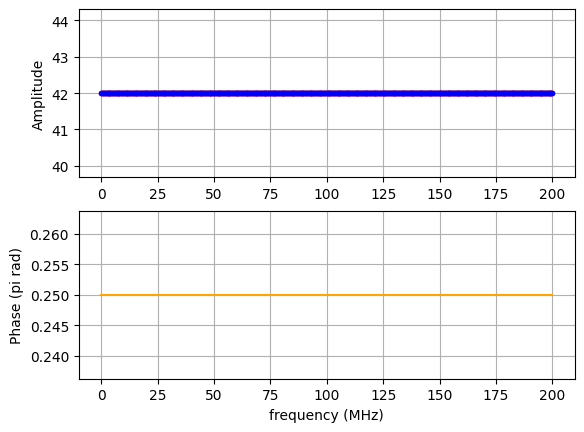

In [ ]:
data_opm = run_opm.get_data("res_spec")
freq_opm = run_opm.get_axis("res_spec")[0]

fig, [ax1,ax2] = plt.subplots(2,1)
ax1.plot(freq_opm/1e6, np.real(data_opm), ".-r")
ax1.plot(freq_opm/1e6, np.imag(data_opm), ".-b")
ax2.plot(freq_opm/1e6, np.unwrap(np.angle(data_opm))/np.pi, "orange")
ax1.set_ylabel("Amplitude")
ax2.set_ylabel("Phase (pi rad)")
ax2.set_xlabel("frequency (MHz)")
ax1.grid()
ax2.grid()
plt.show()